In [1]:
import pandas as pd

In [2]:
ton_iot_dataset = pd.read_csv("train_test_network.csv")
simulation_dataset = pd.read_csv("dataset_training_iot.csv")
testbed_dataset = pd.read_csv("new_dataset_training_iot.csv")

print(f"TON-IoT loaded   : {ton_iot_dataset.shape}")
print(f"Simulation loaded: {simulation_dataset.shape}")
print(f"Testbed loaded   : {testbed_dataset.shape}")

C:\Users\Francis\AppData\Local\Temp\ipykernel_14356\1642136155.py:3: DtypeWarning: Columns (5,15,16,19,20,21,22) have mixed types. Specify dtype option on import or set low_memory=False.
  testbed_dataset = pd.read_csv("new_dataset_training_iot.csv")


TON-IoT loaded   : (211043, 44)
Simulation loaded: (36100, 47)
Testbed loaded   : (504381, 43)


In [3]:
print(ton_iot_dataset['label'].value_counts())
print(ton_iot_dataset['type'].value_counts())

label
1    161043
0     50000
Name: count, dtype: int64
type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
scanning      20000
ransomware    20000
xss           20000
mitm           1043
Name: count, dtype: int64


In [4]:
print(simulation_dataset['label'].value_counts())
print(simulation_dataset['type'].value_counts())

label
1    30986
0     5114
Name: count, dtype: int64
type
injection    5769
normal       5114
ddos         5094
mitm         5086
password     5037
dos          5000
scanning     5000
Name: count, dtype: int64


In [5]:
print(testbed_dataset['label'].value_counts())
print(testbed_dataset['type'].value_counts())

label
1    489538
0     14843
Name: count, dtype: int64
type
ddos         256729
dos          195686
normal        14843
injection     14092
mitm           8396
password       7391
scanning       7244
Name: count, dtype: int64


In [6]:
ton_iot_dataset.head()

,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,...,0,0,-,-,-,-,-,-,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000113,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000130,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor


In [7]:
simulation_dataset.head()

,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,mqtt_topic_len,mqtt_payload_len,mqtt_operation,label,type
0,172.18.0.4,41310,172.18.0.2,1883,tcp,mqtt,0.000326,99,4,SF,...,-,-,-,-,F,30.0,0,2.0,0,normal
1,172.18.0.4,34806,172.18.0.2,1883,tcp,mqtt,0.000443,99,4,SF,...,-,-,-,-,F,30.0,0,2.0,1,mitm
2,172.18.0.2,8377,172.18.0.3,1883,tcp,0,0.000008,0,0,RSTO,...,-,-,-,-,F,0.0,0,0.0,1,dos
3,172.18.0.3,46235,172.18.0.2,4279,tcp,0,0.000002,0,0,REJ,...,-,-,-,-,F,0.0,0,0.0,1,scanning
4,172.18.0.3,46235,172.18.0.2,2004,tcp,0,0.000002,0,0,REJ,...,-,-,-,-,F,0.0,0,0.0,1,scanning


In [8]:
testbed_dataset.head()

,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,ssl_resumed,ssl_established,http_method,http_uri,http_status_code,weird_name,weird_addl,weird_notice,label,type
0,172.19.0.4,43566,172.19.0.2,1883,tcp,mqtt,0.001667,99,4,SF,...,F,F,-,-,0,-,-,F,0,normal
1,172.19.0.4,43580,172.19.0.2,1883,tcp,mqtt,0.000886,95,4,SF,...,F,F,-,-,0,-,-,F,0,normal
2,172.19.0.4,43592,172.19.0.2,1883,tcp,mqtt,0.000515,99,4,SF,...,F,F,-,-,0,-,-,F,0,normal
3,172.19.0.4,43600,172.19.0.2,1883,tcp,mqtt,0.000681,102,4,SF,...,F,F,-,-,0,-,-,F,0,normal
4,172.19.0.4,43610,172.19.0.2,1883,tcp,mqtt,0.000579,99,4,SF,...,F,F,-,-,0,-,-,F,0,normal


In [9]:
ton_iot_dataset.replace("-", "n/a", inplace=True)
simulation_dataset.replace("-", "n/a", inplace=True)
testbed_dataset.replace("-", "n/a", inplace=True)

print(f"TON-IoT loaded   : {ton_iot_dataset.shape}")
print(f"Simulation loaded: {simulation_dataset.shape}")
print(f"Testbed loaded   : {testbed_dataset.shape}")

TON-IoT loaded   : (211043, 44)
Simulation loaded: (36100, 47)
Testbed loaded   : (504381, 43)


In [10]:
DROP_COLS = ['src_ip', 'dst_ip', 'src_port', 'dst_port', 'type']

def drop_meta(df):
    return df.drop(columns=[c for c in DROP_COLS if c in df.columns])

ton_iot_dataset = drop_meta(ton_iot_dataset)
simulation_dataset = drop_meta(simulation_dataset)
testbed_dataset = drop_meta(testbed_dataset)

In [11]:
ton_iot_dataset.head()

,proto,service,duration,src_bytes,dst_bytes,conn_state,missed_bytes,src_pkts,src_ip_bytes,dst_pkts,...,http_request_body_len,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label
0,tcp,n/a,290.371539,101568,2592,OTH,0,108,108064,31,...,0,0,0,n/a,n/a,n/a,n/a,n/a,n/a,1
1,tcp,n/a,0.000102,0,0,REJ,0,1,52,1,...,0,0,0,n/a,n/a,n/a,n/a,n/a,n/a,1
2,tcp,n/a,0.000148,0,0,REJ,0,1,52,1,...,0,0,0,n/a,n/a,n/a,n/a,n/a,n/a,1
3,tcp,n/a,0.000113,0,0,REJ,0,1,48,1,...,0,0,0,n/a,n/a,n/a,n/a,n/a,n/a,1
4,tcp,n/a,0.000130,0,0,REJ,0,1,52,1,...,0,0,0,n/a,n/a,n/a,n/a,n/a,n/a,1


In [12]:
simulation_dataset.head()

,proto,service,duration,src_bytes,dst_bytes,conn_state,missed_bytes,src_pkts,src_ip_bytes,dst_pkts,...,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,mqtt_topic_len,mqtt_payload_len,mqtt_operation,label
0,tcp,mqtt,0.000326,99,4,SF,0,7,471,5,...,n/a,n/a,n/a,n/a,n/a,F,30.0,0,2.0,0
1,tcp,mqtt,0.000443,99,4,SF,0,7,471,5,...,n/a,n/a,n/a,n/a,n/a,F,30.0,0,2.0,1
2,tcp,0,0.000008,0,0,RSTO,0,2,80,1,...,n/a,n/a,n/a,n/a,n/a,F,0.0,0,0.0,1
3,tcp,0,0.000002,0,0,REJ,0,1,44,1,...,n/a,n/a,n/a,n/a,n/a,F,0.0,0,0.0,1
4,tcp,0,0.000002,0,0,REJ,0,1,44,1,...,n/a,n/a,n/a,n/a,n/a,F,0.0,0,0.0,1


In [13]:
testbed_dataset.head()

,proto,service,duration,src_bytes,dst_bytes,conn_state,missed_bytes,src_pkts,src_ip_bytes,dst_pkts,...,ssl_cipher,ssl_resumed,ssl_established,http_method,http_uri,http_status_code,weird_name,weird_addl,weird_notice,label
0,tcp,mqtt,0.001667,99,4,SF,0,7,471,5,...,n/a,F,F,n/a,n/a,0,n/a,n/a,F,0
1,tcp,mqtt,0.000886,95,4,SF,0,7,467,5,...,n/a,F,F,n/a,n/a,0,n/a,n/a,F,0
2,tcp,mqtt,0.000515,99,4,SF,0,7,471,5,...,n/a,F,F,n/a,n/a,0,n/a,n/a,F,0
3,tcp,mqtt,0.000681,102,4,SF,0,7,474,5,...,n/a,F,F,n/a,n/a,0,n/a,n/a,F,0
4,tcp,mqtt,0.000579,99,4,SF,0,7,471,5,...,n/a,F,F,n/a,n/a,0,n/a,n/a,F,0


In [ ]:
all_feature_cols = sorted(
    (set(ton_iot_dataset.columns) | set(simulation_dataset.columns) | set(testbed_dataset.columns)) - {'label'}
)

print(f"TON-IoT features   : {sorted(ton_iot_dataset.columns)}")
print(f"Simulation features: {sorted(simulation_dataset.columns)}")
print(f"Testbed features   : {sorted(testbed_dataset.columns)}")
print(f"All features       : {all_feature_cols}")


TON-IoT features   : ['conn_state', 'dns_AA', 'dns_RA', 'dns_RD', 'dns_qclass', 'dns_qtype', 'dns_query', 'dns_rcode', 'dns_rejected', 'dst_bytes', 'dst_ip_bytes', 'dst_pkts', 'duration', 'http_method', 'http_orig_mime_types', 'http_request_body_len', 'http_resp_mime_types', 'http_response_body_len', 'http_status_code', 'http_trans_depth', 'http_uri', 'http_user_agent', 'http_version', 'label', 'missed_bytes', 'proto', 'service', 'src_bytes', 'src_ip_bytes', 'src_pkts', 'ssl_cipher', 'ssl_established', 'ssl_issuer', 'ssl_resumed', 'ssl_subject', 'ssl_version', 'weird_addl', 'weird_name', 'weird_notice']
Simulation features: ['conn_state', 'dns_AA', 'dns_RA', 'dns_RD', 'dns_qclass', 'dns_qtype', 'dns_query', 'dns_rcode', 'dns_rejected', 'dst_bytes', 'dst_ip_bytes', 'dst_pkts', 'duration', 'http_method', 'http_orig_mime_types', 'http_request_body_len', 'http_resp_mime_types', 'http_response_body_len', 'http_status_code', 'http_trans_depth', 'http_uri', 'http_user_agent', 'http_version', 

In [15]:
def align_columns(df, all_cols):
    """Add any missing feature columns filled with n/a, then reorder."""
    for col in all_cols:
        if col not in df.columns:
            df[col] = 'n/a'
    return df[all_cols + ['label']]

ton_iot_dataset = align_columns(ton_iot_dataset, all_feature_cols)
simulation_dataset = align_columns(simulation_dataset, all_feature_cols)
testbed_dataset = align_columns(testbed_dataset, all_feature_cols)

print(f'Union feature set  : {len(all_feature_cols)} features')
print(f'All datasets shape : TON={ton_iot_dataset.shape}, Simulation={simulation_dataset.shape}, Testbed={testbed_dataset.shape}')

Union feature set  : 47 features
All datasets shape : TON=(211043, 48), Simulation=(36100, 48), Testbed=(504381, 48)


In [16]:
combined_peek = pd.concat([ton_iot_dataset, simulation_dataset, testbed_dataset], ignore_index=True)

categorical_cols = [
    c for c in all_feature_cols
    if combined_peek[c].dtype == object or combined_peek[c].dtype.name == 'category'
]

numeric_cols = [c for c in all_feature_cols if c not in categorical_cols]
print(f'Categorical columns ({len(categorical_cols)}): {categorical_cols}')
print(f'Numeric columns     ({len(numeric_cols)}): {numeric_cols}')

Categorical columns (38): ['conn_state', 'dns_AA', 'dns_RA', 'dns_RD', 'dns_qclass', 'dns_qtype', 'dns_query', 'dns_rcode', 'dns_rejected', 'history', 'http_method', 'http_orig_mime_types', 'http_request_body_len', 'http_resp_mime_types', 'http_response_body_len', 'http_trans_depth', 'http_uri', 'http_user_agent', 'http_version', 'mqtt_from_client', 'mqtt_operation', 'mqtt_payload_len', 'mqtt_qos', 'mqtt_retain', 'mqtt_status', 'mqtt_topic', 'mqtt_topic_len', 'proto', 'service', 'ssl_cipher', 'ssl_established', 'ssl_issuer', 'ssl_resumed', 'ssl_subject', 'ssl_version', 'weird_addl', 'weird_name', 'weird_notice']
Numeric columns     (9): ['dst_bytes', 'dst_ip_bytes', 'dst_pkts', 'duration', 'http_status_code', 'missed_bytes', 'src_bytes', 'src_ip_bytes', 'src_pkts']


In [19]:
from sklearn.preprocessing import  LabelEncoder

encoders = {}
combined_enc = combined_peek.copy()

for col in categorical_cols:
    le = LabelEncoder()
    combined_enc[col] = le.fit_transform(combined_enc[col].astype(str))
    encoders[col] = le

for col in all_feature_cols:
    combined_enc[col] = pd.to_numeric(combined_enc[col], errors='coerce').fillna(0).astype(float)

# Split back into the three source datasets
n_ton = len(ton_iot_dataset)
n_old = len(simulation_dataset)

ton_enc = combined_enc.iloc[:n_ton].reset_index(drop=True)
sim_enc = combined_enc.iloc[n_ton : n_ton + n_old].reset_index(drop=True)
new_enc = combined_enc.iloc[n_ton + n_old :].reset_index(drop=True)

print(f'Encoding done. Shapes: TON={ton_enc.shape}, Old={sim_enc.shape}, New={new_enc.shape}')

Encoding done. Shapes: TON=(211043, 48), Old=(36100, 48), New=(504381, 48)


In [20]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
new_train, new_holdout = train_test_split(
    new_enc,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=new_enc['label']
)

print(f'New testbed train  : {new_train.shape}')
print(f'New testbed holdout: {new_holdout.shape}')
print(f"  Holdout attack % : {new_holdout['label'].mean():.2%}")

New testbed train  : (378285, 48)
New testbed holdout: (126096, 48)
  Holdout attack % : 97.06%


In [21]:
combined_train = pd.concat([ton_enc, sim_enc, new_train], ignore_index=True).dropna()

X = combined_train.drop(columns=['label'])
y = combined_train['label'].astype(int)

X_holdout = new_holdout.drop(columns=['label'])
y_holdout  = new_holdout['label'].astype(int).reset_index(drop=True)

print(f'Combined training set : {X.shape}')
print(f'  Benign samples      : {(y == 0).sum():,}')
print(f'  Attack samples      : {(y == 1).sum():,}')
print(f'  Attack ratio        : {y.mean():.2%}')

Combined training set : (625428, 47)
  Benign samples      : 66,246
  Attack samples      : 559,182
  Attack ratio        : 89.41%


In [22]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Training samples   : {X_train.shape[0]:,}')
print(f'Validation samples : {X_val.shape[0]:,}')

Training samples   : 500,342
Validation samples : 125,086


In [23]:
neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())
raw_spw = neg / pos
spw = min(raw_spw, 10.0)   # cap to avoid over-correction

print(f'Benign (neg)        : {neg:,}')
print(f'Attack (pos)        : {pos:,}')
print(f'Raw scale_pos_weight: {raw_spw:.4f}')
print(f'Capped spw used     : {spw:.4f}')

Benign (neg)        : 52,997
Attack (pos)        : 447,345
Raw scale_pos_weight: 0.1185
Capped spw used     : 0.1185


In [25]:
from xgboost import XGBClassifier
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import StratifiedKFold, cross_val_score

def objective_xgb(trial):
    param = {
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth'        : trial.suggest_int('max_depth', 5, 20),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'min_child_weight' : trial.suggest_float('min_child_weight', 0.5, 2.0),
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 300),
        'max_leaves'        : trial.suggest_int('max_leaves', 1, 9),
        'objective'        : 'binary:logistic',
        'eval_metric'      : 'logloss',
        'scale_pos_weight' : spw,
        'tree_method'      : 'hist',
        'device'           : 'cuda',
        'random_state'     : RANDOM_STATE,
        'n_jobs'           : -1,
    }
    model = XGBClassifier(**param)
    cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
study.optimize(objective_xgb, n_trials=100, show_progress_bar=True)

print(f'\nBest F1 (CV)    : {study.best_value:.4f}')
print('Best parameters :')
for k, v in study.best_params.items():
    print(f'  {k:<22}: {v}')

[I 2026-04-23 10:37:42,098] A new study created in memory with name: no-name-67b85d24-078a-4ae6-979f-e78146b9996c


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-04-23 10:37:53,037] Trial 0 finished with value: 0.9426895663141871 and parameters: {'learning_rate': 0.11861663446573512, 'max_depth': 20, 'subsample': 0.892797576724562, 'min_child_weight': 1.397987726295555, 'n_estimators': 131, 'max_leaves': 2}. Best is trial 0 with value: 0.9426895663141871.
[I 2026-04-23 10:38:02,860] Trial 1 finished with value: 0.9471238660970858 and parameters: {'learning_rate': 0.026844247528777843, 'max_depth': 18, 'subsample': 0.8404460046972835, 'min_child_weight': 1.5621088666940683, 'n_estimators': 104, 'max_leaves': 9}. Best is trial 1 with value: 0.9471238660970858.
[I 2026-04-23 10:38:13,085] Trial 2 finished with value: 0.968682443418701 and parameters: {'learning_rate': 0.2514083658321223, 'max_depth': 8, 'subsample': 0.6727299868828402, 'min_child_weight': 0.7751067647801507, 'n_estimators': 161, 'max_leaves': 5}. Best is trial 2 with value: 0.968682443418701.
[I 2026-04-23 10:38:19,147] Trial 3 finished with value: 0.9647300640542633 and p

In [26]:
best_params = study.best_params.copy()
best_params.update({
    'scale_pos_weight' : spw,
    'objective'        : 'binary:logistic',
    'eval_metric'      : 'logloss',
    'tree_method'      : 'hist',
    'device'           : 'cuda',   # remove if no GPU
    'random_state'     : RANDOM_STATE,
    'n_jobs'           : -1,
})

model = XGBClassifier(**best_params)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

y_val_pred  = model.predict(X_val)
y_val_proba = model.predict_proba(X_val)[:, 1]
print('Model trained.')

[0]	validation_0-logloss:0.52843
[50]	validation_0-logloss:0.10101
[100]	validation_0-logloss:0.08887
[150]	validation_0-logloss:0.08271
[200]	validation_0-logloss:0.07958
[250]	validation_0-logloss:0.07736
[299]	validation_0-logloss:0.07615


C:\Users\Francis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xgboost\core.py:774: UserWarning: [10:55:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Model trained.


In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print('=== VALIDATION SET ===')
print(f'Accuracy  : {accuracy_score(y_val, y_val_pred):.4f}')
print(f'Precision : {precision_score(y_val, y_val_pred):.4f}')
print(f'Recall    : {recall_score(y_val, y_val_pred):.4f}')
print(f'F1        : {f1_score(y_val, y_val_pred):.4f}')
print("Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))
print("Classification Report:\n", classification_report(y_val, y_val_pred))

=== VALIDATION SET ===
Accuracy  : 0.9593
Precision : 0.9991
Recall    : 0.9552
F1        : 0.9767
Confusion Matrix:
 [[ 13158     91]
 [  5005 106832]]
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.99      0.84     13249
           1       1.00      0.96      0.98    111837

    accuracy                           0.96    125086
   macro avg       0.86      0.97      0.91    125086
weighted avg       0.97      0.96      0.96    125086



In [28]:
y_holdout_pred  = model.predict(X_holdout)
y_holdout_proba = model.predict_proba(X_holdout)[:, 1]

print('=== HOLDOUT SET (real IoT deployment) ===')
print(f'Accuracy  : {accuracy_score(y_holdout, y_holdout_pred):.4f}')
print(f'Precision : {precision_score(y_holdout, y_holdout_pred):.4f}')
print(f'Recall    : {recall_score(y_holdout, y_holdout_pred):.4f}')
print(f'F1        : {f1_score(y_holdout, y_holdout_pred):.4f}')
print("Confusion Matrix:\n", confusion_matrix(y_holdout, y_holdout_pred))
print("Classification Report:\n", classification_report(y_holdout, y_holdout_pred))

=== HOLDOUT SET (real IoT deployment) ===
Accuracy  : 0.9618
Precision : 0.9996
Recall    : 0.9610
F1        : 0.9799
Confusion Matrix:
 [[  3660     51]
 [  4769 117616]]
Classification Report:
               precision    recall  f1-score   support

           0       0.43      0.99      0.60      3711
           1       1.00      0.96      0.98    122385

    accuracy                           0.96    126096
   macro avg       0.72      0.97      0.79    126096
weighted avg       0.98      0.96      0.97    126096



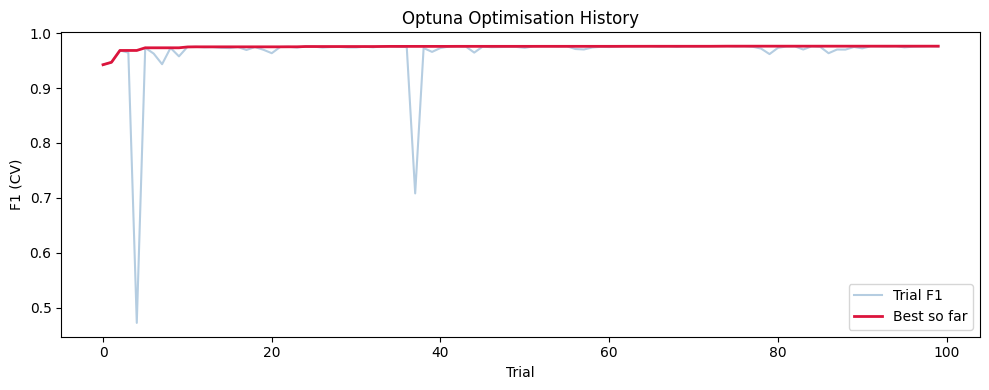

In [29]:
import matplotlib.pyplot as plt

trial_nums   = [t.number for t in study.trials]
trial_vals   = [t.value  for t in study.trials]
best_so_far  = [max(trial_vals[:i+1]) for i in range(len(trial_vals))]

plt.figure(figsize=(10, 4))
plt.plot(trial_nums, trial_vals,  alpha=0.4, color='steelblue', label='Trial F1')
plt.plot(trial_nums, best_so_far, color='crimson', lw=2,         label='Best so far')
plt.xlabel('Trial'); plt.ylabel('F1 (CV)')
plt.title('Optuna Optimisation History')
plt.legend(); plt.tight_layout()
plt.savefig('optuna_history.png', dpi=150)
plt.show()

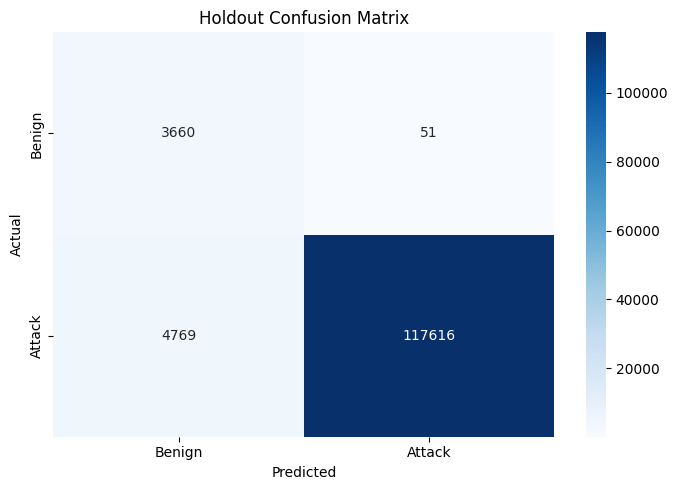

In [44]:
import seaborn as sns

cm = confusion_matrix(y_holdout, y_holdout_pred)

fig, axes = plt.subplots(1, 1, figsize=(7, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes,
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'])
axes.set_title('Holdout Confusion Matrix')
axes.set_ylabel('Actual'); axes.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('holdout_results.png', dpi=150)
plt.show()

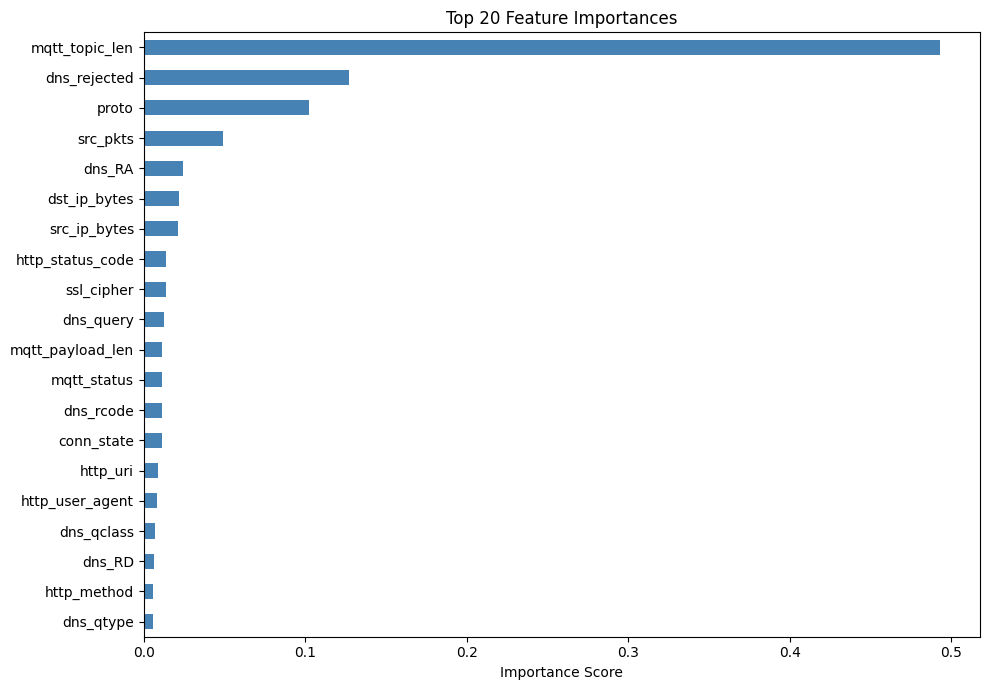

In [45]:
importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 7))
top_features.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title('Top 20 Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [46]:
import json
import joblib

with open('feature_cols.json', 'w') as f:
    json.dump(all_feature_cols, f, indent=2)
print('Saved: feature_cols.json')

params_to_save = study.best_params.copy()
params_to_save['scale_pos_weight'] = spw
with open('best_params.json', 'w') as f:
    json.dump(params_to_save, f, indent=2)
print('Saved: best_params.json')

joblib.dump(model,    'xgb_retrained_final.pkl');    print('Saved: xgb_retrained_final.pkl')
joblib.dump(encoders, 'encoders_retrained_final.pkl'); print('Saved: encoders_retrained_final.pkl')

Saved: feature_cols.json
Saved: best_params.json
Saved: xgb_retrained_final.pkl
Saved: encoders_retrained_final.pkl
